In [1]:
import numpy as np
import pandas as pd
import joblib
from scipy import sparse
from sklearn.model_selection import GroupKFold, cross_validate, GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

# Reload the already-built features
X_train = sparse.load_npz("../data/processed/X_train.npz")
y_train = np.load("../data/processed/y_train.npy")

# Recalculate groups corresponding to the training set (same logic as step 4)
df = pd.read_csv("../data/processed/resume_data_clean.csv")
fallback_ids = pd.Series("missing_resume_" + df.index.astype(str), index=df.index)
group_ids = df["skills"].fillna(fallback_ids)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=group_ids))
groups_train = group_ids.iloc[train_idx].reset_index(drop=True)

print(f"X_train: {X_train.shape} | groups_train: {groups_train.shape}")

X_train: (7519, 438) | groups_train: (7519,)


In [2]:
models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=3, random_state=42
    ),
}

In [3]:
gkf = GroupKFold(n_splits=5)
scoring = ["neg_mean_squared_error", "neg_mean_absolute_error", "r2"]

results = {}

for name, model in models.items():
    print(f"Cross-validation: {name}...")
    cv_results = cross_validate(
        model, X_train, y_train,
        groups=groups_train,
        cv=gkf,
        scoring=scoring,
        n_jobs=-1,
    )
    results[name] = cv_results
    print(f"  → done\n")

Cross-validation: Ridge...
  → done

Cross-validation: Random Forest...
  → done

Cross-validation: Gradient Boosting...
  → done



In [4]:
summary_rows = []
for name, cv_results in results.items():
    summary_rows.append({
        "Model": name,
        "MSE (mean ± std)": f"{-cv_results['test_neg_mean_squared_error'].mean():.4f} ± {cv_results['test_neg_mean_squared_error'].std():.4f}",
        "MAE (mean ± std)": f"{-cv_results['test_neg_mean_absolute_error'].mean():.4f} ± {cv_results['test_neg_mean_absolute_error'].std():.4f}",
        "R² (mean ± std)": f"{cv_results['test_r2'].mean():.4f} ± {cv_results['test_r2'].std():.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

           Model MSE (mean ± std) MAE (mean ± std)  R² (mean ± std)
            Ridge 0.0206 ± 0.0015 0.1128 ± 0.0045 0.2330 ± 0.0670
    Random Forest 0.0141 ± 0.0008 0.0907 ± 0.0023 0.4776 ± 0.0141
Gradient Boosting 0.0149 ± 0.0010 0.0943 ± 0.0035 0.4462 ± 0.0101


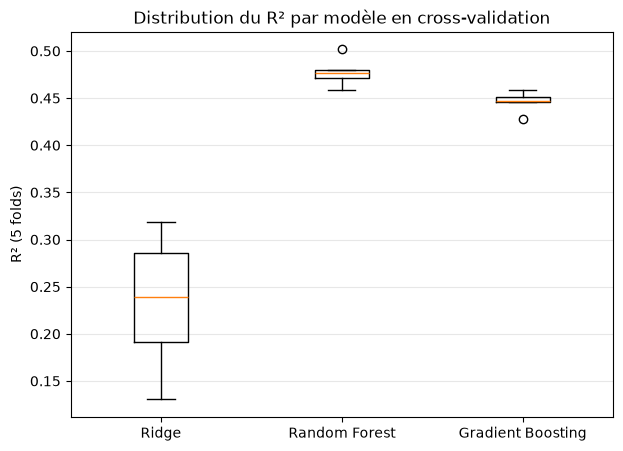

      Ridge  Random Forest  Gradient Boosting
0  0.319033       0.479918           0.451517
1  0.191114       0.471126           0.458568
2  0.130381       0.477134           0.446154
3  0.239254       0.501602           0.447031
4  0.285172       0.458287           0.427949


In [5]:
r2_data = {name: cv_results["test_r2"] for name, cv_results in results.items()}
r2_df = pd.DataFrame(r2_data)

plt.figure(figsize=(7, 5))
plt.boxplot(r2_df.values, tick_labels=r2_df.columns)
plt.ylabel("R² (5 folds)")
plt.title("R² distribution by model in cross-validation")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(r2_df)

In [6]:
summary_df.to_csv("../data/processed/cv_results_summary.csv", index=False)
r2_df.to_csv("../data/processed/cv_r2_by_fold.csv", index=False)
print("Cross-validation results saved.")

Cross-validation results saved.
